# NicheSphere tutorial (CODEX)

NicheSphere is an sc-verse compatible Python library for finding differentially co-localised cellular niches based on cell type pair co-localization probabilities across conditions. Cell type pair co-localization probabilities are derived from the probability of finding each cell type in the same spatial neighborhood.

This tutorial demonstrates NicheSphere on single-cell resolved spatial data from **CODEX** imaging, where co-localization is quantified using a radius-based neighborhood approach rather than spot deconvolution.


## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import scipy
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import networkx as nx
import warnings
import scanpy as sc
from sklearn.neighbors import NearestNeighbors
from community_layout.layout_class import CommunityLayout

warnings.filterwarnings("ignore")

import nichesphere


COMMUNITY LAYOUT: Datashader not found, edge bundling not available


## 2. Load data

We load the processed CODEX AnnData object, which contains cell type annotations and spatial coordinates.


In [2]:
adata = sc.read('../data/CODEX/final_data/CODEX_run45_anndata_final.h5ad')
adata.obs.head()


,orig.ident,total_arcsinh_intensity_bgFilt,nFeature,condition,sample,run,total_arcsinh_intensity_bgFilt_SCT,nFeature_SCT,SCT_snn_res.0.2,seurat_clusters,SCT_snn_res.0.1,SCT_snn_res.0.3,SCT_snn_res.0.4,SCT_snn_res.0.5,mask,clusters_named,Spp1_pos
0_run46_EV_1,CODEX_fusion_run46,3.881087,4,EV,run46_EV_1,run46,4,3,3,Megakaryocytes,2,3,4,3,1.0,Megakaryocytes,Spp1+
1_run46_EV_1,CODEX_fusion_run46,3.935102,5,EV,run46_EV_1,run46,3,2,3,Megakaryocytes,2,3,4,3,1.0,Megakaryocytes,Negative
2_run46_EV_1,CODEX_fusion_run46,3.270065,4,EV,run46_EV_1,run46,4,3,3,Megakaryocytes,2,3,4,3,1.0,Megakaryocytes,Negative
3_run46_EV_1,CODEX_fusion_run46,3.283810,5,EV,run46_EV_1,run46,4,3,3,Megakaryocytes,2,3,4,3,1.0,Megakaryocytes,Spp1+
4_run46_EV_1,CODEX_fusion_run46,3.106023,4,EV,run46_EV_1,run46,3,2,3,Megakaryocytes,2,3,4,3,1.0,Megakaryocytes,Negative


In [3]:
adata.obs.clusters_named.unique()


['Megakaryocytes', 'Spp1+_Osteolineage_cells', 'Sinusoidal_endothelial_cells', 'Perivascular_myofibroblasts', 'Activated_MSCs_CAR_cells', ..., 'Pericytes', 'CD45+_hematopoietic_cells', 'Spp1+_Immune', 'Myofibroblasts', 'Vascular_endothelial_cells']
Length: 12
Categories (12, object): ['CD45+_hematopoietic_cells', 'Perivascular_myofibroblasts', 'Sinusoidal_endothelial_cells', 'Megakaryocytes', ..., 'Pericytes', 'Spp1+_Sinusoidal_pericytes', 'Spp1+_Immune', 'Spp1+_Osteolineage_cells']

## 3. Co-localization

Co-localization probabilities per cell type pair were quantified using a radius-based approach (radius = 600 pixels ≈ 300 µm). This was pre-computed in `019_CODEX_coloc_radius.py` and saved as a CSV.


In [4]:
CTcolocalizationP = pd.read_csv(
    '../res_data/revision/CODEX/CODEX_run45_CTcolocalizationP_radius600_final.csv', index_col=0
)
CTcolocalizationP.head()


,CD45+_hematopoietic_cells,Perivascular_myofibroblasts,Sinusoidal_endothelial_cells,Megakaryocytes,Erythroid_lineage,Myofibroblasts,Activated_MSCs_CAR_cells,Vascular_endothelial_cells,Pericytes,Spp1+_Sinusoidal_pericytes,Spp1+_Immune,Spp1+_Osteolineage_cells,sample
CD45+_hematopoietic_cells,0.106206,0.034607,0.040860,0.016758,0.047349,0.006858,0.020671,0.005312,0.004536,0.003915,0.020206,0.006059,run46_EV_1
Perivascular_myofibroblasts,0.034607,0.019854,0.017711,0.006833,0.017575,0.004065,0.008047,0.001564,0.001846,0.002171,0.007339,0.003577,run46_EV_1
Sinusoidal_endothelial_cells,0.040860,0.017711,0.019689,0.007401,0.017992,0.003190,0.007906,0.002426,0.002122,0.002370,0.009399,0.003531,run46_EV_1
Megakaryocytes,0.016758,0.006833,0.007401,0.002870,0.007734,0.001304,0.003222,0.000905,0.000800,0.000770,0.003455,0.001191,run46_EV_1
Erythroid_lineage,0.047349,0.017575,0.017992,0.007734,0.024540,0.003890,0.010846,0.001956,0.002038,0.001797,0.008967,0.003086,run46_EV_1


We extract the cell type list and build a list of same-cell-type pairs (e.g. `Fibro-Fibro`), which will be excluded from the differential co-localization analysis.


In [5]:
cell_types = CTcolocalizationP.columns[:-1]
oneCTints = cell_types + '-' + cell_types
print(f"{len(cell_types)} cell types, {len(oneCTints)} same-cell-type pairs")


12 cell types, 12 same-cell-type pairs


### Reshape into cell type pair × sample matrix

`reshapeColoc` converts the co-localization table into a matrix of cell type pairs × samples. Set `complete=1` if both directions of each pair (`ct1-ct2` and `ct2-ct1`) are present.

Co-localization probabilities across all pairs should sum to 1 per sample.


In [6]:
colocPerSample = nichesphere.coloc.reshapeColoc(CTcoloc=CTcolocalizationP, complete=1)
colocPerSample.sum(axis=1)


run46_EV_1      1.0
run46_Thpo_2    1.0
dtype: float64

In [7]:
colocPerSample


,CD45+_hematopoietic_cells-CD45+_hematopoietic_cells,CD45+_hematopoietic_cells-Perivascular_myofibroblasts,CD45+_hematopoietic_cells-Sinusoidal_endothelial_cells,CD45+_hematopoietic_cells-Megakaryocytes,CD45+_hematopoietic_cells-Erythroid_lineage,CD45+_hematopoietic_cells-Myofibroblasts,CD45+_hematopoietic_cells-Activated_MSCs_CAR_cells,CD45+_hematopoietic_cells-Vascular_endothelial_cells,CD45+_hematopoietic_cells-Pericytes,CD45+_hematopoietic_cells-Spp1+_Sinusoidal_pericytes,...,Spp1+_Osteolineage_cells-Sinusoidal_endothelial_cells,Spp1+_Osteolineage_cells-Megakaryocytes,Spp1+_Osteolineage_cells-Erythroid_lineage,Spp1+_Osteolineage_cells-Myofibroblasts,Spp1+_Osteolineage_cells-Activated_MSCs_CAR_cells,Spp1+_Osteolineage_cells-Vascular_endothelial_cells,Spp1+_Osteolineage_cells-Pericytes,Spp1+_Osteolineage_cells-Spp1+_Sinusoidal_pericytes,Spp1+_Osteolineage_cells-Spp1+_Immune,Spp1+_Osteolineage_cells-Spp1+_Osteolineage_cells
run46_EV_1,0.106206,0.034607,0.040860,0.016758,0.047349,0.006858,0.020671,0.005312,0.004536,0.003915,...,0.003531,0.001191,0.003086,0.000587,0.001516,0.000329,0.000365,0.000572,0.001777,0.000948
run46_Thpo_2,0.042537,0.020963,0.017266,0.036217,0.012740,0.028155,0.023801,0.004929,0.001692,0.000557,...,0.002650,0.004758,0.002206,0.004785,0.002996,0.000842,0.000217,0.000274,0.000133,0.001806


### Sample–condition mapping

We build a sample × condition table to keep track of which samples belong to which condition.


In [8]:
sampleTypesDF = adata.obs[['sample', 'condition']].drop_duplicates()
sampleTypesDF = sampleTypesDF.reset_index(drop=True)
sampleTypesDF.columns = ['sample', 'sampleType']
sampleTypesDF.index = sampleTypesDF['sample']
sampleTypesDF = sampleTypesDF.loc[colocPerSample.index]
sampleTypesDF


,sample,sampleType
run46_EV_1,run46_EV_1,EV
run46_Thpo_2,run46_Thpo_2,Thpo


In [9]:
sampleTypesDF.sampleType.unique()


['EV', 'Thpo']
Categories (2, object): ['EV', 'Thpo']

## 4. Differential co-localization

Since we do not have replicate samples per condition, we test differential co-localization by comparing observed co-localization probabilities to a background distribution.

### Background distribution

The background was generated by running the same radius-based co-localization approach on CODEX slices with **randomized cell type labels** (1000 permutations per slice), using `019_CODEX_coloc_radius.py`. The mean of each pair's distribution across permutations is used as the expected co-localization value.


In [10]:
df_Thpo = pd.read_csv('../res_data/revision/CODEX/run46_Thpo_2_600_testDistribution_df_final.csv', index_col=0)
df_EV   = pd.read_csv('../res_data/revision/CODEX/run46_EV_1_600_testDistribution_df_final.csv',   index_col=0)

scCTpairsProbs_TPO = df_Thpo.mean()
scCTpairsProbs_EV  = df_EV.mean()


### Observed vs. expected log2 ratios

`OvsE_coloc_test_adjPval` computes log2(observed / expected) co-localization ratios, filters out non-significant values at a given p-value threshold, and removes same-cell-type pairs. We run this for both conditions and visualize the results as clustered heatmaps.


Text(0.5, 1.02, 'EV condition')

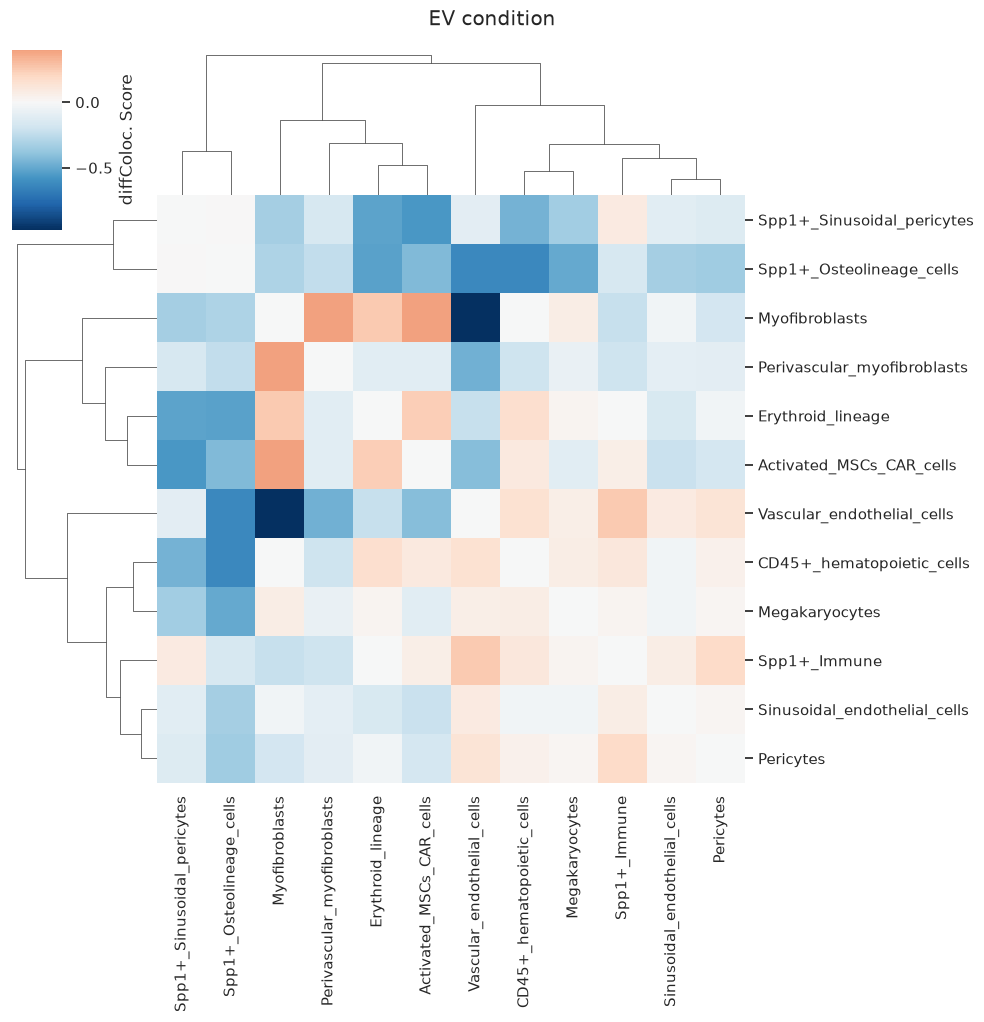

In [11]:
OvsE_EV_HMdf, statsEV = nichesphere.coloc.OvsE_coloc_test_adjPval(
    observedColocProbs=colocPerSample.loc['run46_EV_1'],
    expectedColocProbs=scCTpairsProbs_EV,
    cell_types=cell_types,
    testDistribution_df=df_EV,
    oneCTinteractions=oneCTints,
    p=0.05
)

sns.set(font_scale=1)
sns.clustermap(OvsE_EV_HMdf, cmap='RdBu_r', center=0, method='ward',
               cbar_kws={'label': 'diffColoc. Score'})
plt.suptitle('EV condition', y=1.02)


In [12]:
statsEV.head(20)


,statistic,pvalue,adjusted_pvalue
CD45+_hematopoietic_cells-CD45+_hematopoietic_cells,0.000000,0.0,0.0
CD45+_hematopoietic_cells-Perivascular_myofibroblasts,-0.204555,0.0,0.0
CD45+_hematopoietic_cells-Sinusoidal_endothelial_cells,-0.041197,0.0,0.0
CD45+_hematopoietic_cells-Megakaryocytes,0.071028,0.0,0.0
CD45+_hematopoietic_cells-Erythroid_lineage,0.166916,0.0,0.0
CD45+_hematopoietic_cells-Myofibroblasts,-0.000905,0.0,0.0
CD45+_hematopoietic_cells-Activated_MSCs_CAR_cells,0.097195,0.0,0.0
CD45+_hematopoietic_cells-Vascular_endothelial_cells,0.146277,0.0,0.0
CD45+_hematopoietic_cells-Pericytes,0.045660,0.0,0.0
CD45+_hematopoietic_cells-Spp1+_Sinusoidal_pericytes,-0.465160,0.0,0.0


Text(0.5, 1.02, 'TPO condition')

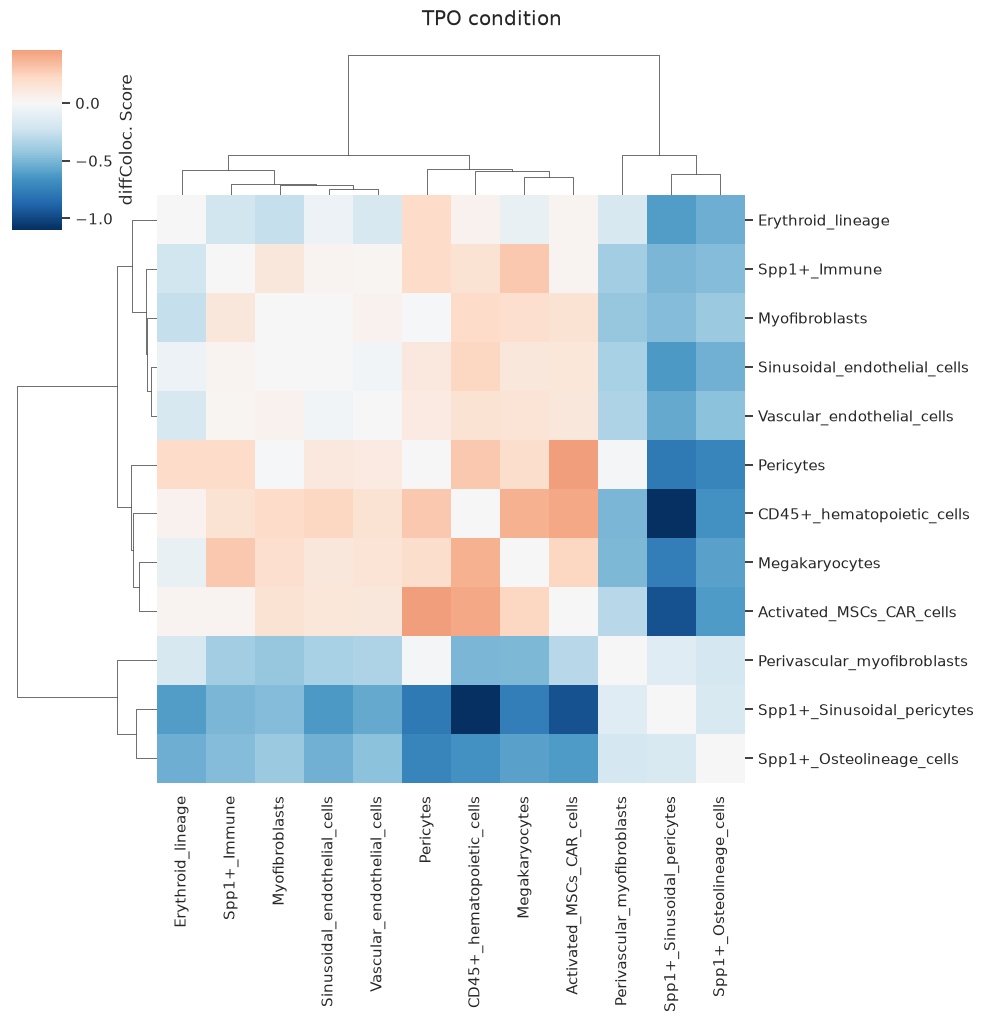

In [13]:
OvsE_TPO_HMdf, statsTPO = nichesphere.coloc.OvsE_coloc_test_adjPval(
    observedColocProbs=colocPerSample.loc['run46_Thpo_2'],
    expectedColocProbs=scCTpairsProbs_TPO,
    cell_types=cell_types,
    testDistribution_df=df_Thpo,
    oneCTinteractions=oneCTints,
    p=0.05
)

sns.set(font_scale=1)
sns.clustermap(OvsE_TPO_HMdf, cmap='RdBu_r', center=0, method='ward',
               cbar_kws={'label': 'diffColoc. Score'})
plt.suptitle('TPO condition', y=1.02)


In [14]:
statsTPO.head(20)


,statistic,pvalue,adjusted_pvalue
CD45+_hematopoietic_cells-CD45+_hematopoietic_cells,0.000000,0.0,0.0
CD45+_hematopoietic_cells-Perivascular_myofibroblasts,-0.502709,0.0,0.0
CD45+_hematopoietic_cells-Sinusoidal_endothelial_cells,0.230906,0.0,0.0
CD45+_hematopoietic_cells-Megakaryocytes,0.386225,0.0,0.0
CD45+_hematopoietic_cells-Erythroid_lineage,0.048547,0.0,0.0
CD45+_hematopoietic_cells-Myofibroblasts,0.204791,0.0,0.0
CD45+_hematopoietic_cells-Activated_MSCs_CAR_cells,0.425978,0.0,0.0
CD45+_hematopoietic_cells-Vascular_endothelial_cells,0.158049,0.0,0.0
CD45+_hematopoietic_cells-Pericytes,0.297001,0.0,0.0
CD45+_hematopoietic_cells-Spp1+_Sinusoidal_pericytes,-1.099599,0.0,0.0


## 5. Differential co-localization network

We focus on the **TPO condition** for the network analysis.

### Adjacency matrix

The adjacency matrix is built from Euclidean distances between differential co-localization profiles. Cell pairs with no significant differential co-localization receive a weight of 0.


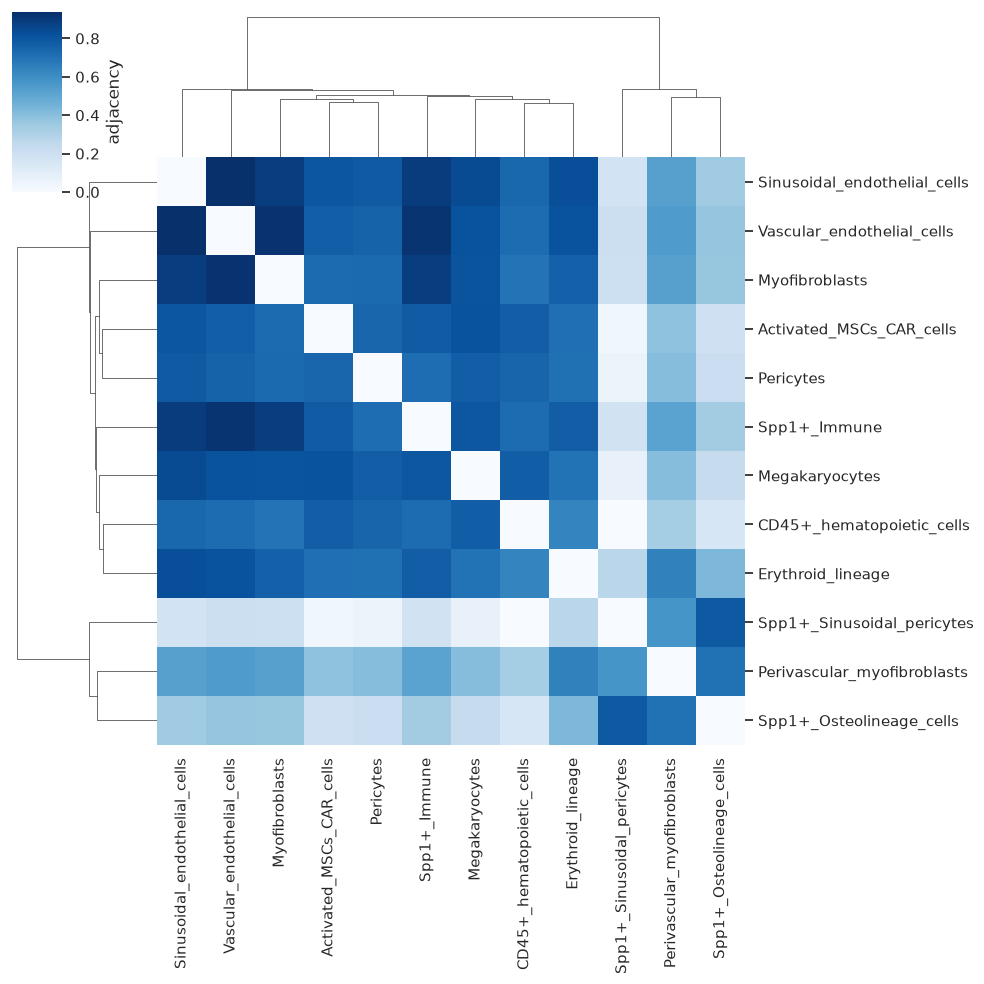

In [15]:
HMdist = pd.DataFrame(
    scipy.spatial.distance.squareform(scipy.spatial.distance.pdist(OvsE_TPO_HMdf)),
    columns=OvsE_TPO_HMdf.columns,
    index=OvsE_TPO_HMdf.index
)

HMsimm = 1 - HMdist / HMdist.max().max()
HMsimm[OvsE_TPO_HMdf == 0] = 0

sns.set(font_scale=1)
sns.clustermap(HMsimm, cmap='Blues', method='ward', cbar_kws={'label': 'adjacency'})


### Initial network (before niche detection)

We first plot the network with all nodes in a single placeholder group, using a `neato` layout. This gives a visual overview before community detection.


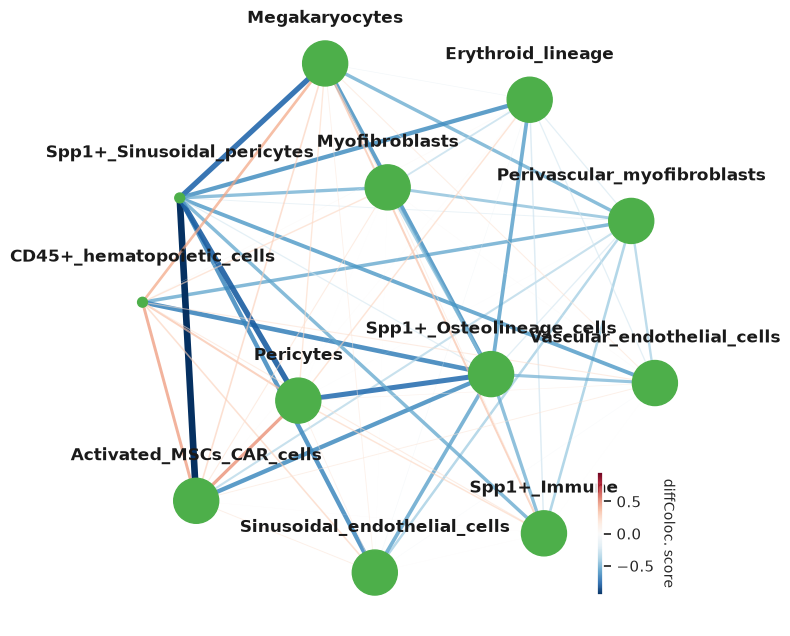

In [16]:
niches_dict = {'1_': list(OvsE_TPO_HMdf.index)}
clist = ['#4daf4a']

plt.rcParams['axes.facecolor'] = 'None'
gCol = nichesphere.coloc.colocNW(
    x_diff=OvsE_TPO_HMdf, adj=HMsimm,
    cell_group=niches_dict, clist=clist,
    nodeSize='betweeness', layout='neato', edge_scale=5, thr=0
)


### Niche detection

We detect communities (niches) in the unsigned network using Louvain clustering.


In [17]:
gCol2 = nx.from_pandas_adjacency(HMsimm, create_using=nx.Graph)

d = nx.algorithms.community.louvain_communities(gCol2, resolution=1.15, seed=1, weight='weight')
niches_dict = dict(enumerate([list(x) for x in d]))
niches_dict


{0: ['Spp1+_Immune', 'Vascular_endothelial_cells', 'Myofibroblasts'],
 1: ['Pericytes',
  'Activated_MSCs_CAR_cells',
  'Megakaryocytes',
  'Sinusoidal_endothelial_cells',
  'CD45+_hematopoietic_cells'],
 2: ['Spp1+_Osteolineage_cells',
  'Erythroid_lineage',
  'Perivascular_myofibroblasts',
  'Spp1+_Sinusoidal_pericytes']}

In [18]:
niche_names = ['1_Spp1_immune_niche', '2_Fibrosis_interacting_core', '3_Osteo_niche']
niches_dict = dict(zip(niche_names, list(niches_dict.values())))

# Assign a color to each niche
cmap_tab10 = plt.colormaps['tab10'].resampled(10)
cmap_set1  = plt.colormaps['Set1'].resampled(9)
clist = (
    [mcolors.rgb2hex(cmap_tab10(9)[:3])] +
    [mcolors.rgb2hex(cmap_set1(i)[:3]) for i in [7, 2]]
)

niche_cols = pd.Series(clist, index=list(niches_dict.keys()))
niches_df  = nichesphere.tl.cells_niche_colors(CTs=cell_types, niche_colors=niche_cols, niche_dict=niches_dict)


### Community-aware layout

We use `CommunityLayout` to position nodes so that detected niches are spatially grouped. The resulting layout can be saved and reloaded to keep a consistent appearance across figures.


In [19]:
cl = CommunityLayout(
    gCol2,
    community_compression=0.35,
    layout_algorithm=nx.spring_layout,
    layout_kwargs={"k": 75, "iterations": 1000},
    community_algorithm=nx.algorithms.community.louvain_communities,
    community_kwargs={"resolution": 1.15, "seed": 1, "weight": "weight"}
)


Building meta-graph
Metagraph is a Graph with 3 nodes and 3 edges


100%|██████████| 3/3 [00:00<00:00, 384.76it/s]


In [20]:
# Load pre-saved node positions for reproducibility (or use cl.full_positions for a fresh layout)
pos = np.load('../res_data/revision/CODEX/diffColocNW_node_positions_final.npy', allow_pickle=True).item()


### Final network plot


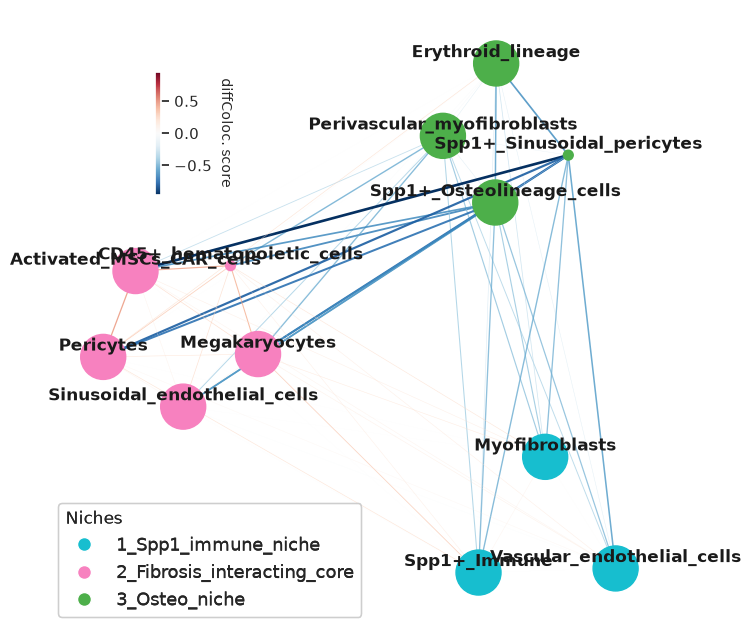

In [21]:
plt.rcParams['axes.facecolor'] = 'None'

gCol = nichesphere.coloc.colocNW(
    x_diff=OvsE_TPO_HMdf,
    adj=HMsimm,
    cell_group=niches_dict,
    clist=clist,
    nodeSize='betweeness',
    layout=None,          # None = use provided node positions
    lab_spacing=0.05,
    thr=0,
    pos=pos,
    edge_scale=2,
    legend_ax=[0.05, 0.7, 0.15, 0.2]
)

legend_elements = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=clist[i],
               lw=4, label=list(niches_dict.keys())[i], ms=10)
    for i in range(len(niches_dict))
]
plt.gca().add_artist(
    plt.legend(handles=legend_elements, loc='lower left', fontsize=13, title='Niches', alignment='left')
)
plt.savefig('../figures/revision/F3/F3E.pdf')


In [22]:
# Save node positions for future reuse
np.save('../res_data/revision/CODEX/diffColocNW_node_positions_final.npy', pos)


In [23]:
nichesphere.tl.assign_properties(
    gCol,
    communities=cl.communities(),
    colors=clist,
    pos=pos,
    simmilarity_weights=True,
    node_coord_sf=100,
    g_unsigned=gCol2
)


### Interactive network

The `gravis` library enables an interactive D3-based network visualization where node sizes, edge widths, and label sizes can be adjusted in the browser.

> **Note:** gravis may require downgrading setuptools: `pip install --force-reinstall -U "setuptools<82.0.0"`


In [24]:
import gravis as gv
gv.d3(gCol, edge_size_data_source='weight_abs', zoom_factor=0.35, layout_algorithm_active=False)


## 6. Network statistics

We compute betweenness centrality, PageRank, and signed degree centrality (split into positive and negative edges) using NetworkX.


In [25]:
nw_stats = nichesphere.tl.compute_network_stats(gCol)
nw_stats.head()


,betweenness,pagerank,degree_positive,degree_negative
CD45+_hematopoietic_cells,28.553398,1.969366,0.727273,0.181818
Perivascular_myofibroblasts,-30.852959,-2.833025,0.000000,1.000000
Sinusoidal_endothelial_cells,24.852959,0.196267,0.545455,0.454545
Megakaryocytes,25.852959,1.136218,0.636364,0.363636
Erythroid_lineage,-28.607846,-0.907684,0.272727,0.727273


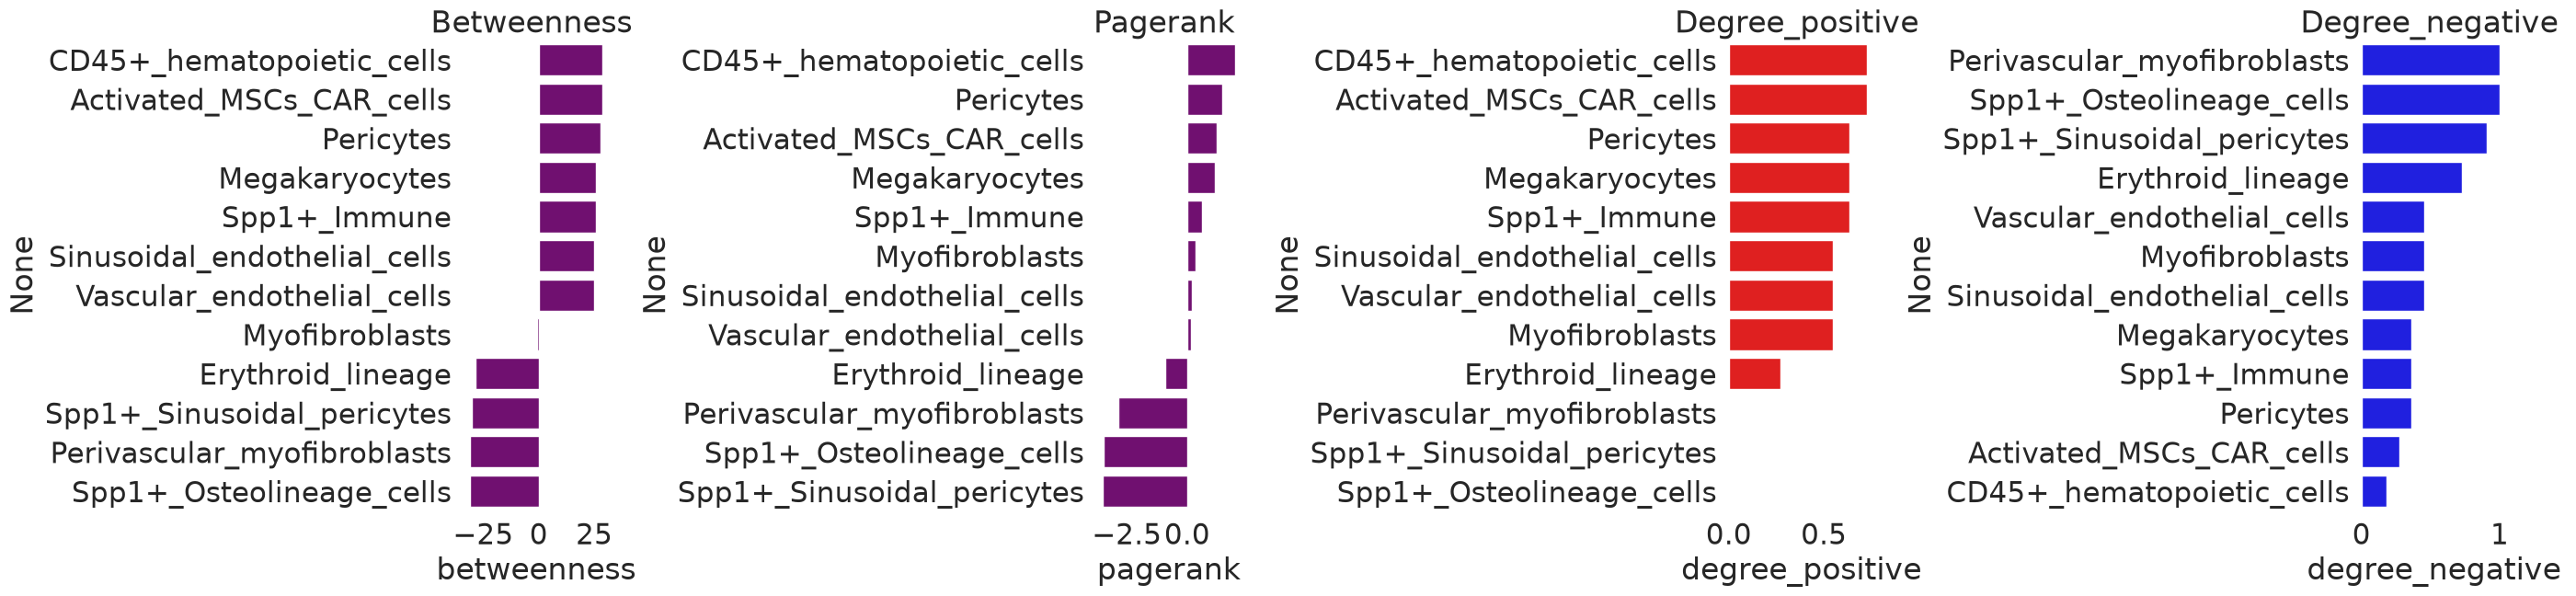

In [26]:
sns.set(font_scale=2)
plt.rcParams['axes.facecolor'] = 'None'
fig = nichesphere.tl.plot_top_stats(nw_stats)
plt.savefig('../figures/revision/FS3/FS3E.pdf', bbox_inches='tight')
